In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../../data/noisy.csv")
df.head(5)

,Unnamed: 0,review,model,sentiment
0,0,The movie was a complete .tsefezoons I detterg...,Gemini-1.5-Flash,negative
1,1,"Seriously, the worst venue I've ever been to. ...",Gemini-1.5-Flash,negative
2,2,"This event was so pooly organized, it was a .e...",Gemini-1.5-Flash,negative
3,3,What a risadset of a movie! The acting was awf...,Gemini-1.5-Flash,negative
4,4,I wouldn't cdemrmeon this venue to my worst en...,Gemini-1.5-Flash,negative


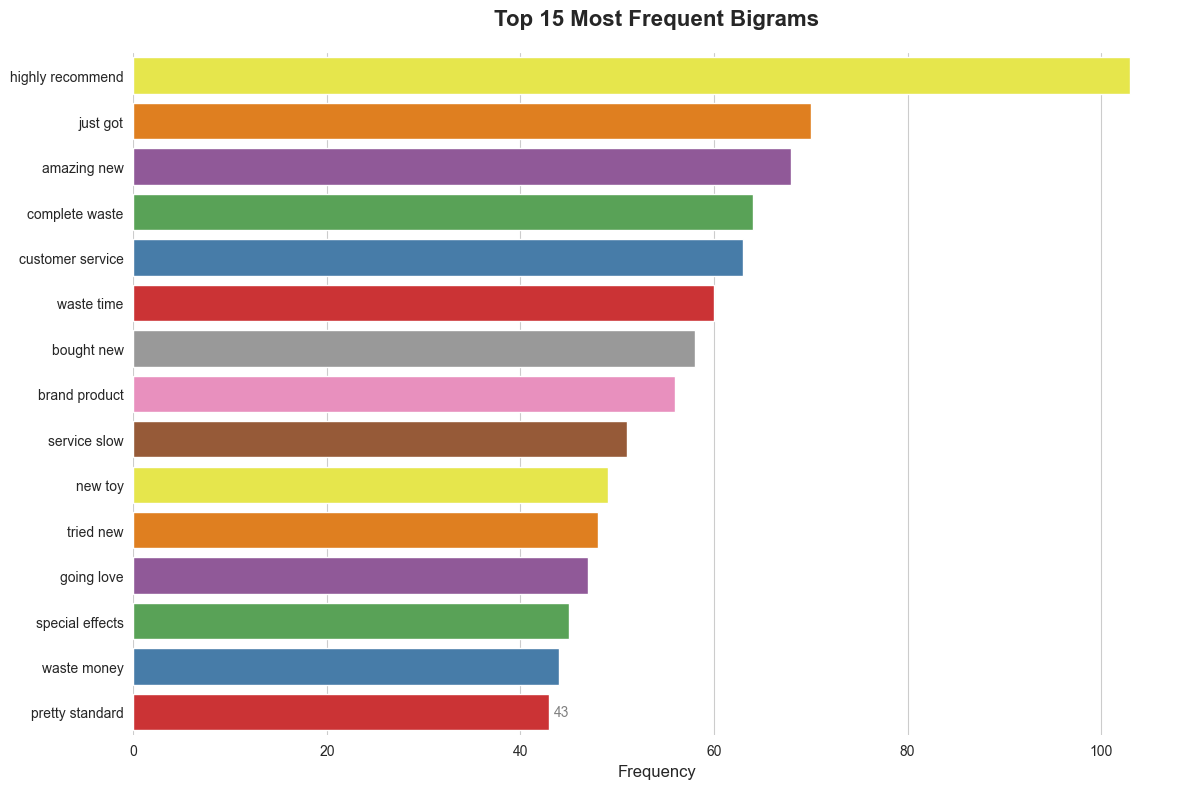

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
def get_top_ngrams(corpus, n=2, top_k=10):
    """
    Optimized n-gram extractor.
    Uses min_df to ignore extremely rare typos and better memory handling.
    """
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words='english',
        min_df=2 # Only include n-grams that appear at least twice
    ).fit(corpus)

    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    # Efficiently mapping vocabulary to sums
    words_freq = [
        (word, sum_words[0, idx])
        for word, idx in vec.vocabulary_.items()
    ]

    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

# --- 1. Data Preparation ---
top_bigrams = get_top_ngrams(df['review'], n=2, top_k=15)
ngram_df = pd.DataFrame(top_bigrams, columns=['Phrase', 'Count'])

# --- 2. Advanced Plotting ---
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Use a gradient palette based on the actual values
ax = sns.barplot(
    data=ngram_df,
    x='Count',
    y='Phrase',
    hue='Count',        # Color intensity based on frequency
    palette='Set1',
    legend=False
)

# Add value labels to the end of each bar for clarity
ax.bar_label(ax.containers[0], padding=3, fontsize=10, color='gray')

# Formatting Refinement
plt.title('Top 15 Most Frequent Bigrams', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel(None) # Phrases are self-explanatory
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

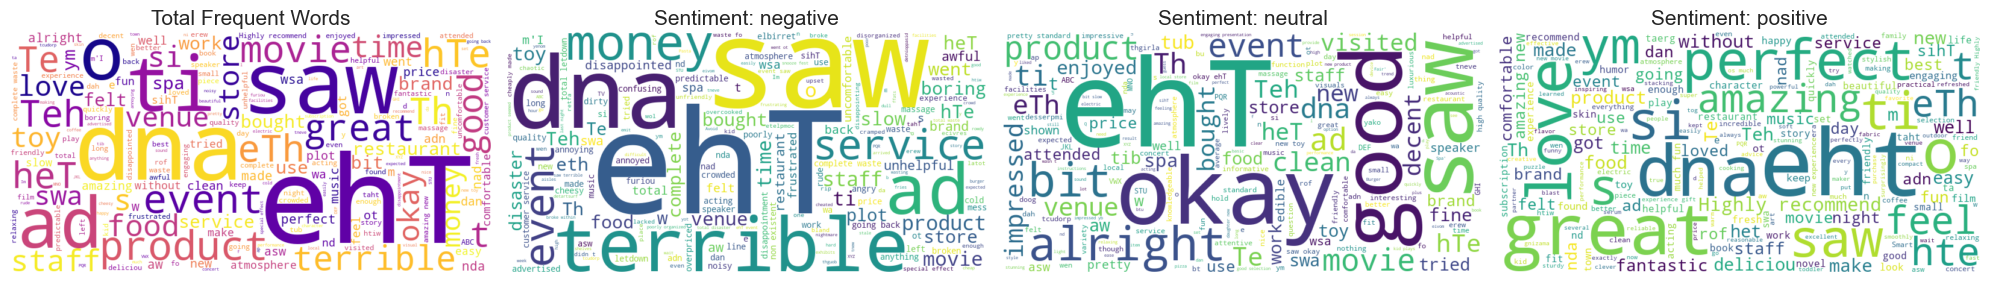

In [4]:
from wordcloud import WordCloud

def plot_wordclouds(df, text_col, sentiment_col):
    # 1. Total Word Cloud
    total_text = " ".join(review for review in df[text_col].astype(str))

    # 2. Split by Sentiment (Assuming labels like 'positive', 'negative')
    sentiments = df[sentiment_col].unique()

    # Setup plotting grid
    fig, axes = plt.subplots(1, len(sentiments) + 1, figsize=(20, 10))

    # Plot Total
    wc_total = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(total_text)
    axes[0].imshow(wc_total, interpolation='bilinear')
    axes[0].set_title('Total Frequent Words', fontsize=15)
    axes[0].axis('off')

    # Plot per Sentiment
    for i, s in enumerate(sentiments):
        s_text = " ".join(review for review in df[df[sentiment_col] == s][text_col].astype(str))
        wc_s = WordCloud(width=800, height=400, background_color='white').generate(s_text)

        axes[i+1].imshow(wc_s, interpolation='bilinear')
        axes[i+1].set_title(f'Sentiment: {s}', fontsize=15)
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

# Execute
plot_wordclouds(df, 'review', 'sentiment')

In [14]:
df['review_len'] = df['review'].apply(lambda x: len(str(x).split()))

In [15]:
def calculate_ttr(text):
    tokens = text.lower().split()
    if not tokens: return 0
    return len(set(tokens)) / len(tokens)

df['lexical_diversity'] = df['review'].apply(calculate_ttr)

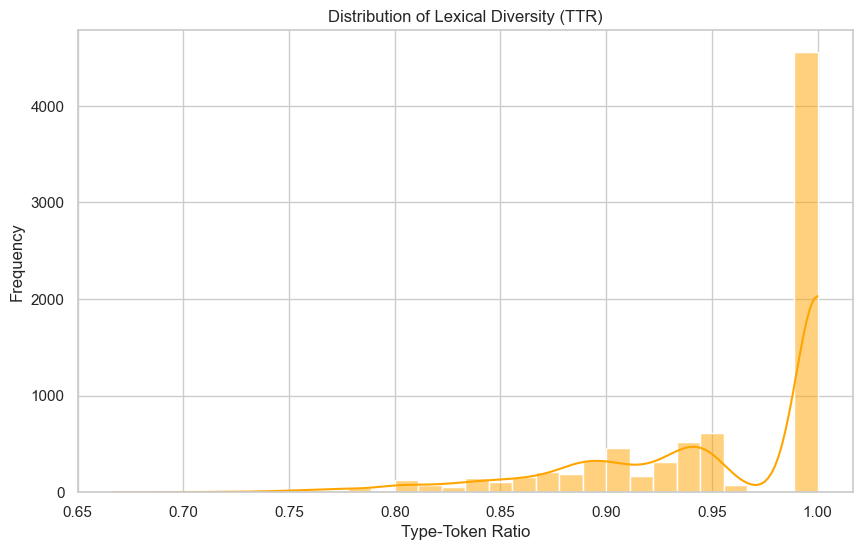

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['lexical_diversity'], bins=30, kde=True, color='orange')
plt.title('Distribution of Lexical Diversity (TTR)')
plt.xlabel('Type-Token Ratio')
plt.ylabel('Frequency')
plt.show()

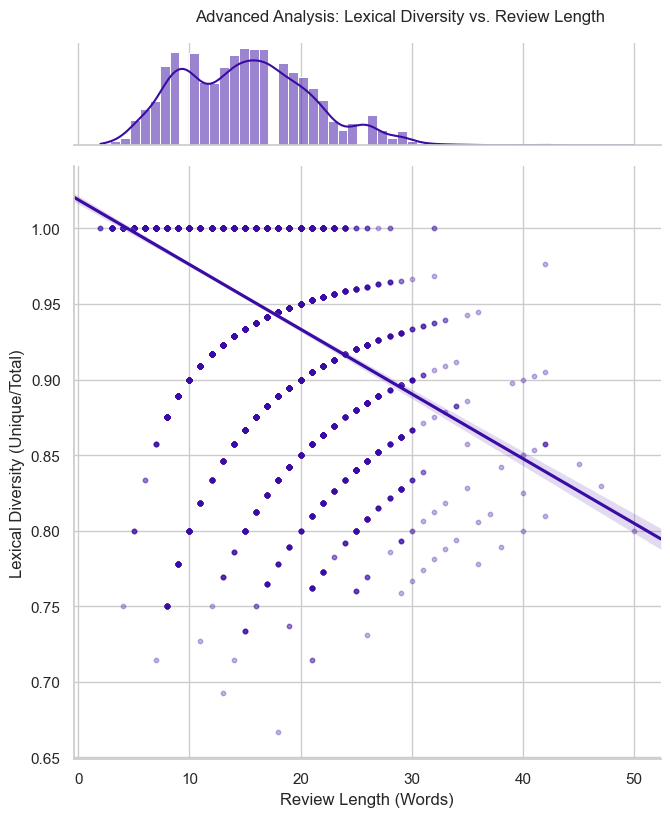

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Setting a clean, professional style
sns.set_theme(style="whitegrid")

# Create the advanced visualization
g = sns.jointplot(
    data=df,
    x='review_len',
    y='lexical_diversity',
    kind="reg",
    truncate=False,
    color="#3A0CA3",
    height=8,
    scatter_kws={'alpha': 0.3, 's': 10}
)

# --- This is the key line to remove the right-side plot ---
g.ax_marg_y.set_visible(False)

# Refine titles and labels
g.fig.suptitle('Advanced Analysis: Lexical Diversity vs. Review Length', y=1.02, fontsize=12)
g.set_axis_labels('Review Length (Words)', 'Lexical Diversity (Unique/Total)', fontsize=12)

plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your datasets
# Replace these filenames with your actual file paths
df_clean = pd.read_csv('../../data/processed.csv')
df_noisy = pd.read_csv('../../data/noisy.csv')

# --- Data Preparation ---
# Assuming your CSVs have columns named 'Accuracy' and 'Error'
# If they are single rows, we extract the values:
metrics = ['Accuracy', 'Error']

# Extracting values (Adjust indexing if your CSV has multiple rows/different structure)
clean_vals = [df_clean['Accuracy'].iloc[0], df_clean['Error'].iloc[0]]
noisy_vals = [df_noisy['Accuracy'].iloc[0], df_noisy['Error'].iloc[0]]

# --- Plotting ---
x = np.arange(len(metrics))  # Label locations
width = 0.35                 # Width of the bars

fig, ax = plt.subplots(figsize=(8, 6))

# Create grouped bars
rects1 = ax.bar(x - width/2, clean_vals, width, label='Clean Data', color='#4C72B0')
rects2 = ax.bar(x + width/2, noisy_vals, width, label='Noisy Data', color='#C44E52')

# Add labels and formatting
ax.set_ylabel('Score / Percentage')
ax.set_title('Model Performance: Clean vs. Noisy Data')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save and show the plot
plt.savefig('accuracy_vs_error_comparison.png')
plt.show()

KeyError: 'Accuracy'

In [1]:
import os, psutil
process = psutil.Process(os.getpid())
print(f"Memory used: {process.memory_info().rss / 1024 / 1024:.2f} MiB")

Memory used: 235.19 MiB
